# Resultados das buscas heurísticas — N-Puzzle

Este notebook lê `resultados/resultados_heuristicas.csv` e compara Gulosa, A* e IDA* por tempo de execução, número de movimentos e nós expandidos, apresentando média, desvio padrão e os valores nas barras dos gráficos.


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

ARQUIVO_RESULTADOS = os.path.join(
    "resultados",
    "resultados_heuristicas.csv"
)

df = pd.read_csv(ARQUIVO_RESULTADOS)

ordem_algoritmos = [
    "Gulosa",
    "A*",
    "IDA*"
]

df["algoritmo"] = pd.Categorical(
    df["algoritmo"],
    categories=ordem_algoritmos,
    ordered=True
)

df.head()


,tamanho_puzzle,quantidade_tabuleiros,execucao,algoritmo,seed,resolvido,movimentos,nos_expandidos,tempo_ms,caminho
0,3,100,1,Gulosa,3634436724326302442,True,48,253,1.5326,"0,2,5/6,7,1/8,3,4;6,2,5/0,7,1/8,3,4;6,2,5/7,0,..."
1,3,100,1,A*,3634436724326302442,True,24,1360,8.7200,"0,2,5/6,7,1/8,3,4;6,2,5/0,7,1/8,3,4;6,2,5/7,0,..."
2,3,100,1,IDA*,3634436724326302442,True,24,1943,10.8916,"0,2,5/6,7,1/8,3,4;6,2,5/0,7,1/8,3,4;6,2,5/7,0,..."
3,3,100,2,Gulosa,147458239665590913,True,44,120,1.3110,"5,4,6/3,7,1/2,8,0;5,4,6/3,7,1/2,0,8;5,4,6/3,0,..."
4,3,100,2,A*,147458239665590913,True,20,192,1.3240,"5,4,6/3,7,1/2,8,0;5,4,6/3,7,1/2,0,8;5,4,6/3,0,..."


Tempo de execução (ms): média e desvio padrão


Média (ms)                               Desvio padrão (ms)  \
algoritmo          Gulosa             A*           IDA*             Gulosa   
tamanho_puzzle                                                               
3                1.868176      10.311172      12.570002           1.135460   
4               70.018374  116024.043075  119485.619611          29.773422   

                                              
algoritmo                  A*           IDA*  
tamanho_puzzle                                
3                   12.003218      16.019148  
4               149573.255449  166994.476774

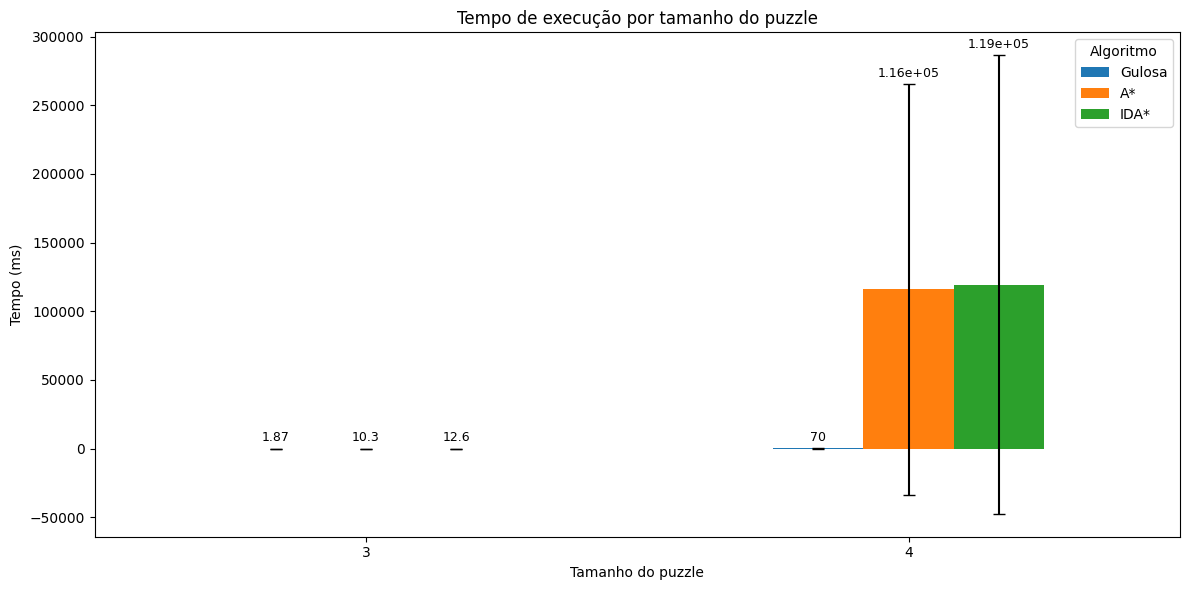

In [6]:
# Tempo médio e desvio padrão por tamanho do puzzle
tempo_estatisticas = (
    df.groupby(["tamanho_puzzle", "algoritmo"], observed=True)["tempo_ms"]
      .agg(["mean", "std"])
      .rename(columns={"mean": "media", "std": "desvio_padrao"})
      .unstack()
)

tempo_medio = (
    tempo_estatisticas["media"]
      .reindex(columns=ordem_algoritmos)
)

tempo_desvio = (
    tempo_estatisticas["desvio_padrao"]
      .reindex(columns=ordem_algoritmos)
)

print("Tempo de execução (ms): média e desvio padrão")
display(
    pd.concat(
        {
            "Média (ms)": tempo_medio,
            "Desvio padrão (ms)": tempo_desvio
        },
        axis=1
    )
)

ax = tempo_medio.plot(
    kind="bar",
    figsize=(12, 6),
    yerr=tempo_desvio,
    capsize=4
)

ax.set_title("Tempo de execução por tamanho do puzzle")
ax.set_xlabel("Tamanho do puzzle")
ax.set_ylabel("Tempo (ms)")
ax.legend(title="Algoritmo")
plt.xticks(rotation=0)

for container in ax.containers:
    if hasattr(container, "patches"):
        ax.bar_label(
            container,
            fmt="%.3g",
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()


Movimentos: média e desvio padrão


Média                       Desvio padrão                    
algoritmo       Gulosa         A*       IDA*        Gulosa        A*      IDA*
tamanho_puzzle                                                                
3                43.47  21.983333  21.983333     12.361166  3.391370  3.391370
4               144.80  48.800000  48.800000     26.883080  5.357238  5.357238

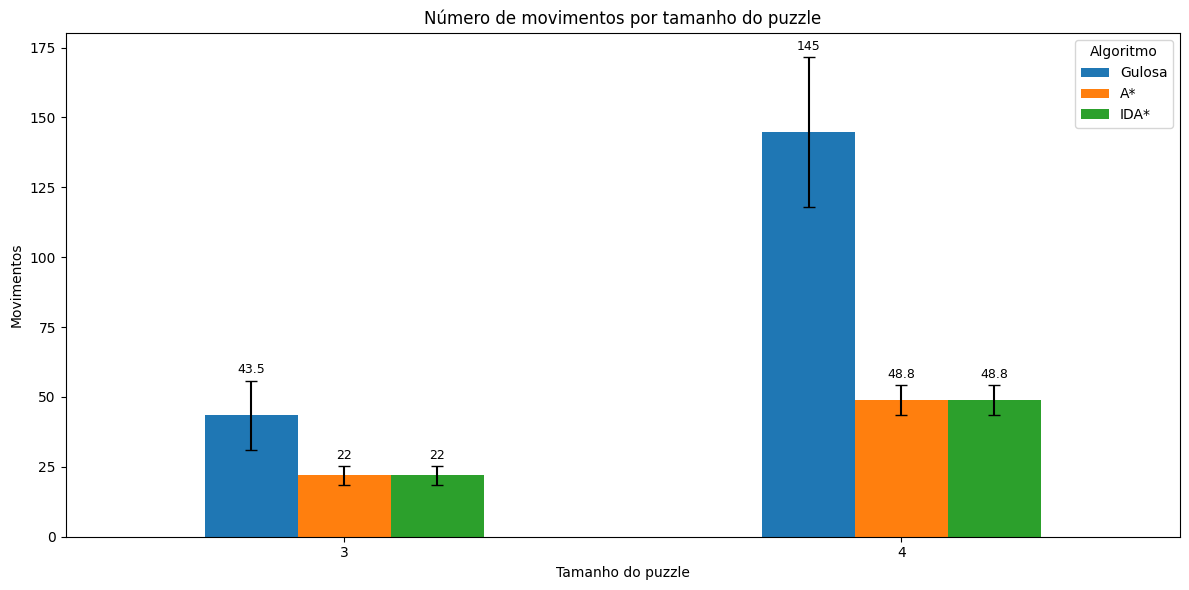

In [7]:
# Número médio de movimentos e desvio padrão por tamanho do puzzle
movimentos_estatisticas = (
    df.groupby(["tamanho_puzzle", "algoritmo"], observed=True)["movimentos"]
      .agg(["mean", "std"])
      .rename(columns={"mean": "media", "std": "desvio_padrao"})
      .unstack()
)

movimentos_medio = (
    movimentos_estatisticas["media"]
      .reindex(columns=ordem_algoritmos)
)

movimentos_desvio = (
    movimentos_estatisticas["desvio_padrao"]
      .reindex(columns=ordem_algoritmos)
)

print("Movimentos: média e desvio padrão")
display(
    pd.concat(
        {
            "Média": movimentos_medio,
            "Desvio padrão": movimentos_desvio
        },
        axis=1
    )
)

ax = movimentos_medio.plot(
    kind="bar",
    figsize=(12, 6),
    yerr=movimentos_desvio,
    capsize=4
)

ax.set_title("Número de movimentos por tamanho do puzzle")
ax.set_xlabel("Tamanho do puzzle")
ax.set_ylabel("Movimentos")
ax.legend(title="Algoritmo")
plt.xticks(rotation=0)

for container in ax.containers:
    if hasattr(container, "patches"):
        ax.bar_label(
            container,
            fmt="%.3g",
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()


Nós expandidos: média e desvio padrão


Média                             Desvio padrão  \
algoritmo            Gulosa            A*          IDA*        Gulosa   
tamanho_puzzle                                                          
3                281.183333  1.593823e+03  1.992537e+03    167.095980   
4               2656.000000  4.579498e+06  6.061596e+06    944.215283   

                                            
algoritmo                 A*          IDA*  
tamanho_puzzle                              
3               1.766585e+03  2.467250e+03  
4               5.769542e+06  8.315381e+06

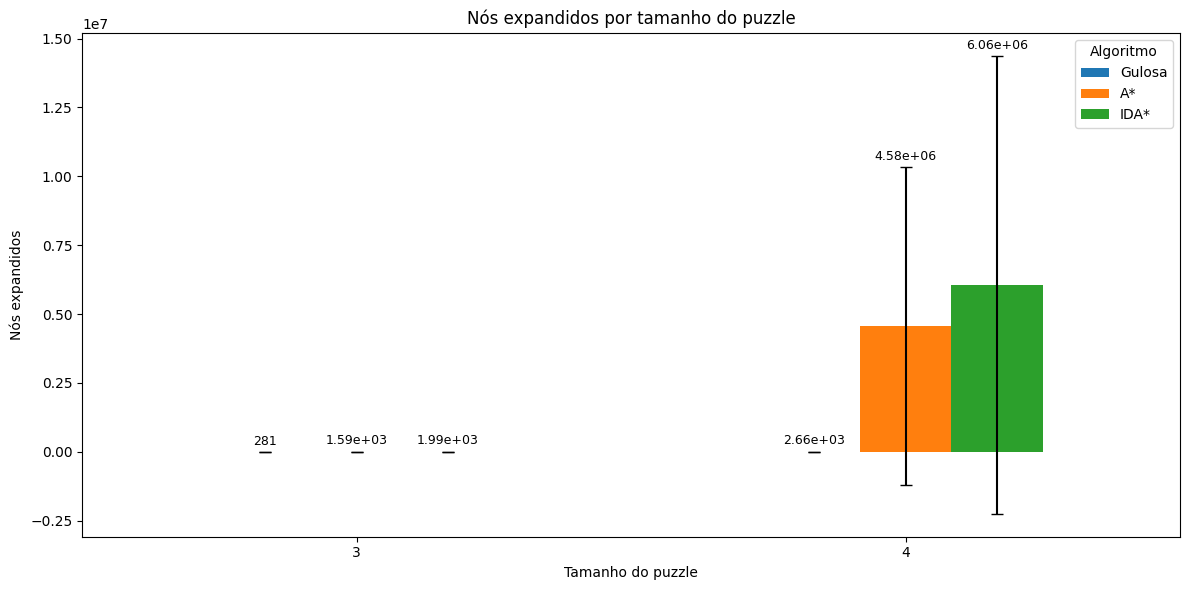

In [8]:
# Nós expandidos: média e desvio padrão por tamanho do puzzle
nos_estatisticas = (
    df.groupby(["tamanho_puzzle", "algoritmo"], observed=True)["nos_expandidos"]
      .agg(["mean", "std"])
      .rename(columns={"mean": "media", "std": "desvio_padrao"})
      .unstack()
)

nos_medio = (
    nos_estatisticas["media"]
      .reindex(columns=ordem_algoritmos)
)

nos_desvio = (
    nos_estatisticas["desvio_padrao"]
      .reindex(columns=ordem_algoritmos)
)

print("Nós expandidos: média e desvio padrão")
display(
    pd.concat(
        {
            "Média": nos_medio,
            "Desvio padrão": nos_desvio
        },
        axis=1
    )
)

ax = nos_medio.plot(
    kind="bar",
    figsize=(12, 6),
    yerr=nos_desvio,
    capsize=4
)

ax.set_title("Nós expandidos por tamanho do puzzle")
ax.set_xlabel("Tamanho do puzzle")
ax.set_ylabel("Nós expandidos")
ax.legend(title="Algoritmo")
plt.xticks(rotation=0)

for container in ax.containers:
    if hasattr(container, "patches"):
        ax.bar_label(
            container,
            fmt="%.3g",
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()
